In [2]:
import pandas as pd

# 1. The Historical Data
data = {
    'Exam_1_Score': [34.6, 30.2, 35.8, 60.1, 79.0, 45.0, 61.1, 75.2, 76.6, 90.5],
    'Exam_2_Score': [78.0, 43.8, 72.9, 86.3, 75.3, 56.3, 96.5, 46.5, 87.2, 88.0],
    'Admitted':     [0,    0,    0,    1,    1,    0,    1,    1,    1,    1]
}

df = pd.DataFrame(data)

# Splitting into Features (X) and Target (y)
X = df[['Exam_1_Score', 'Exam_2_Score']]
y = df['Admitted']

In [4]:

import numpy as np
from sklearn.linear_model import LogisticRegression

#### Sigmoid Function

In [13]:
def sigmoid(z):

    return 1/(1+np.exp(-z))

#### Fit the model

In [6]:
model = LogisticRegression()
model.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Get weight and bias

In [12]:
w = model.coef_[0]
b = model.intercept_[0]

print("Learned Weight:", w)
print("Learned Bias:", b)

Learned Weight: [0.37025141 0.13091217]
Learned Bias: -28.73004006744739


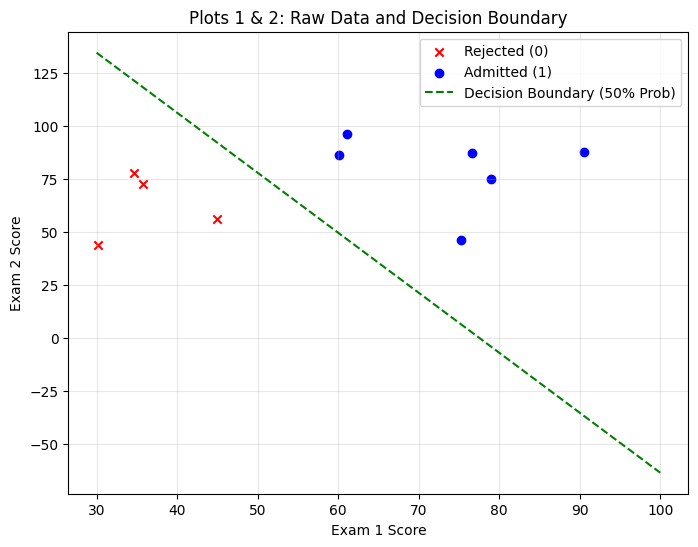

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PLOT 1 & 2: Scatter Plot + Decision Boundary
# ==========================================

# Safely ensure X and y are NumPy arrays, no matter what they currently are
X = np.array(X)
y = np.array(y)

# Extract the weights and bias from your trained model
w1, w2 = model.coef_[0]
b = model.intercept_[0]

# Now the exact same plotting code will work perfectly!
plt.figure(figsize=(8, 6))

# Plot the raw data points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', marker='x', label='Rejected (0)')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='o', label='Admitted (1)')

# Calculate the Decision Boundary line (where w1*x1 + w2*x2 + b = 0)
x1_values = np.array([30, 100]) 
x2_values = -(w1 * x1_values + b) / w2 

plt.plot(x1_values, x2_values, color='green', linestyle='--', label='Decision Boundary (50% Prob)')

plt.title("Plots 1 & 2: Raw Data and Decision Boundary")
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

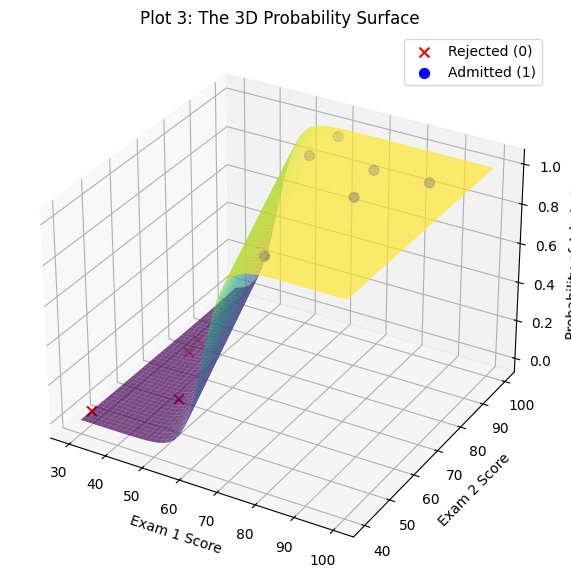

In [24]:
# ==========================================
# PLOT 3: The 3D Sigmoid Surface
# ==========================================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Create a grid of all possible Exam 1 and Exam 2 scores
xx1, xx2 = np.meshgrid(np.linspace(30, 100, 50), np.linspace(40, 100, 50))

# Calculate z = w1*x1 + w2*x2 + b for every point on the grid
z_grid = w1 * xx1 + w2 * xx2 + b

# Pass z through the sigmoid function to get probabilities
probabilities = 1 / (1 + np.exp(-z_grid))

# Plot the 3D surface
surf = ax.plot_surface(xx1, xx2, probabilities, cmap='viridis', alpha=0.7)

# Overlay our actual students on the 3D plot (at z=0 and z=1)
ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], 0, color='red', marker='x', s=50, label='Rejected (0)')
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], 1, color='blue', marker='o', s=50, label='Admitted (1)')

ax.set_title("Plot 3: The 3D Probability Surface")
ax.set_xlabel("Exam 1 Score")
ax.set_ylabel("Exam 2 Score")
ax.set_zlabel("Probability of Admission")
plt.legend()
plt.show()

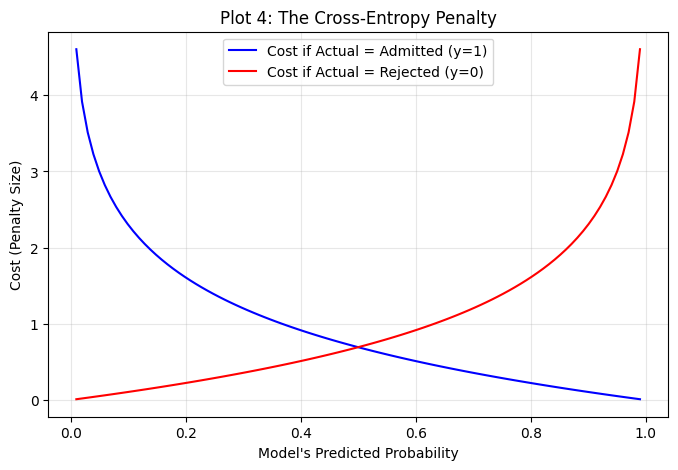

In [25]:
# ==========================================
# PLOT 4: Log Loss (Cross-Entropy) Curves
# ==========================================
plt.figure(figsize=(8, 5))

# Create an array of predicted probabilities from 0.01 to 0.99
p = np.linspace(0.01, 0.99, 100)

# Calculate costs
cost_if_admitted = -np.log(p)        # Cost when actual y = 1
cost_if_rejected = -np.log(1 - p)    # Cost when actual y = 0

plt.plot(p, cost_if_admitted, color='blue', label='Cost if Actual = Admitted (y=1)')
plt.plot(p, cost_if_rejected, color='red', label='Cost if Actual = Rejected (y=0)')

plt.title("Plot 4: The Cross-Entropy Penalty")
plt.xlabel("Model's Predicted Probability")
plt.ylabel("Cost (Penalty Size)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Classify new score

In [14]:
x_new = np.array([45.0, 85.0])

# Calculate z
z = np.dot(w, x_new) + b

# Probability
p = sigmoid(z)

print(f"Manual probability of admission: {p:.4f}")

Manual probability of admission: 0.2807


#### If built in function used

When you run model.predict_proba(), it doesn't just return one number. It returns a 2D array containing the probabilities for both classes: [Probability of 0, Probability of 1].

In [19]:
PbuiltIn = model.predict_proba(x_new.reshape(1,-1))
print(f"Calculated probability of admission: {PbuiltIn}")

Calculated probability of admission: [[0.71934043 0.28065957]]


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
